# Описание используемого набора данных

* В качестве исходных данных в работе использовалась база **NOAA Oil Library**, представляющая собой открытый набор данных, содержащий физико-химические характеристики различных образцов нефти.

* Данный набор данных включает информацию о свойствах нефти, таких как плотность, вязкость, температура вспышки и застывания, компонентный состав (SARA-анализ), содержание серы и другие параметры. Данные представлены в формате JSON и имеют сложную вложенную структуру.

* База NOAA Oil Library широко используется в научных исследованиях и прикладных задачах, связанных с анализом нефти и моделированием её поведения в окружающей среде.

* В рамках данной работы исходные данные были преобразованы в табличный формат и использованы для построения моделей машинного обучения, направленных на классификацию нефти по типу (light, medium, heavy).

**Подключение внешнего хранилища данных**. Для загрузки данных использовалось подключение Google Drive к среде Google Colab.

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
data = []

# folder = "/content/drive/MyDrive/diplom_oil/oil"
folder = "oil"
TARGET_TEMP = 15

**Разработка функций извлечения и обработки признаков**. Реализованы функции для извлечения, унификации и преобразования признаков из JSON-структуры, включая приведение данных к единой температуре и единицам измерения, а также формирование целевой переменной.

In [8]:
def get_closest_value(items, value_key):
    closest_item = None
    min_diff = float("inf")

    for item in items:
        temp = item.get("ref_temp", {}).get("value")
        if temp is None:
            continue

        diff = abs(temp - TARGET_TEMP)

        if diff < min_diff:
            min_diff = diff
            closest_item = item

    if closest_item:
        return closest_item[value_key]["value"]

    return None


def get_closest_viscosity(items):
    closest_item = None
    min_diff = float("inf")

    for item in items:
        temp = item.get("ref_temp", {}).get("value")
        if temp is None:
            continue

        diff = abs(temp - TARGET_TEMP)

        if diff < min_diff:
            min_diff = diff
            closest_item = item

    if closest_item:
        value = closest_item["viscosity"]["value"]
        unit = closest_item["viscosity"].get("unit")

        # Приводим к mPa·s
        if unit == "Pa.s":
            value = value * 1000
        elif unit == "mPa.s":
            value = value
        elif unit == "cP":
            value = value

        return value

    return None


def get_simple_measurement(obj, key):
    try:
        return obj[key]["measurement"]["value"]
    except:
        return None


def get_sara(sample):
    sara = sample.get("SARA", {})
    return {
        "saturates": sara.get("saturates", {}).get("value"),
        "aromatics": sara.get("aromatics", {}).get("value"),
        "resins": sara.get("resins", {}).get("value"),
        "asphaltenes": sara.get("asphaltenes", {}).get("value"),
    }


def get_sulfur(sample):
    bulk = sample.get("bulk_composition", [])
    for item in bulk:
        if item.get("name") == "Sulfur Content":
            return item.get("measurement", {}).get("value")
    return None


def classify_oil(api):
    if api > 31:
        return "light"
    elif api > 22:
        return "medium"
    else:
        return "heavy"


**Извлечение и формирование набора данных**. Выполняется обход всех JSON-файлов, извлечение признаков и формирование единого набора данных для последующего анализа.

In [9]:
import json
import os


for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".json"):
            with open(os.path.join(root, file)) as f:
                oil = json.load(f)

                try:
                    api = oil["metadata"].get("API")

                    sample = oil["sub_samples"][0]
                    phys = sample.get("physical_properties", {})

                    densities = phys.get("densities", [])
                    viscosities = phys.get("dynamic_viscosities", [])

                    density = get_closest_value(densities, "density")
                    viscosity = get_closest_viscosity(viscosities)

                    pour_point = get_simple_measurement(phys, "pour_point")
                    flash_point = get_simple_measurement(phys, "flash_point")

                    sara = get_sara(sample)
                    sulfur = get_sulfur(sample)

                    if api and density and viscosity:
                        data.append({
                            "API": api,
                            "density": density,
                            "viscosity": viscosity,
                            "pour_point": pour_point,
                            "flash_point": flash_point,
                            "saturates": sara["saturates"],
                            "aromatics": sara["aromatics"],
                            "resins": sara["resins"],
                            "asphaltenes": sara["asphaltenes"],
                            "sulfur": sulfur,
                            "class": classify_oil(api)
                        })

                except:
                    continue

**Формирование и очистка набора данных**. Выполнено формирование DataFrame, удаление критических пропусков и заполнение остальных значений средними, а также анализ структуры данных.

In [18]:
%pip install pandas -q
%pip install matplotlib -q
%pip install seaborn -q
%pip install scikit-learn -q


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd


df = pd.DataFrame(data)

print("До очистки:", df.shape)

# удаляем только ключевые пропуски
df = df.dropna(subset=["density", "viscosity", "class"])

# остальные заполняем средним
df = df.fillna(df.mean(numeric_only=True))

print("После очистки:", df.shape)
print(df.head())
print(df["class"].value_counts())

До очистки: (618, 11)
После очистки: (618, 11)
     API   density  viscosity  pour_point  flash_point  saturates  aromatics  \
0  34.89    0.8496      13.00   -21.00000    -9.000000  45.727049  20.331417   
1  29.50    0.8783      29.00   -10.00000   -13.000000  54.000000  32.000000   
2  30.20    0.8743      13.00   -27.00000   -14.000000  51.000000  36.000000   
3  11.00  992.1200       0.42    50.40783    39.356379  45.727049  20.331417   
4  10.90    0.9930  485500.00    21.00000    57.000000  25.000000  35.000000   

      resins  asphaltenes    sulfur   class  
0   8.016063          1.0  1.944429   light  
1   7.000000          6.0  1.944429  medium  
2   9.000000          5.0  1.944429  medium  
3   8.016063          0.1  1.944429   heavy  
4  22.000000         18.0  1.944429   heavy  
class
light     332
medium    143
heavy     143
Name: count, dtype: int64


**Подключение библиотек машинного обучения**. Подключены библиотеки для построения моделей, масштабирования данных и оценки качества классификации.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, accuracy_score


**Подготовка данных и кросс-валидация моделей**. Выполнено разделение данных на признаки и целевую переменную, проведена кросс-валидация, разбиение на обучающую и тестовую выборки, а также нормализация данных.

In [20]:
X = df.drop(columns=["class", "API"])
y = df["class"]


# Cross validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Нормализация (важно для Logistic и KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cross-validation scores: [0.96774194 0.96774194 0.95967742 0.92682927 0.94308943]
Mean accuracy: 0.9530159979019146


**Выбор и инициализация моделей машинного обучения**. Определён набор моделей (Logistic Regression, Random Forest, KNN) для последующего сравнения их эффективности.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

**Обучение моделей и сравнительный анализ**. Выполнено обучение моделей, получение предсказаний и сравнение их качества с использованием метрик классификации.

In [22]:

results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))

    results.append((name, acc))


=== Logistic Regression ===
Accuracy: 0.7338709677419355
              precision    recall  f1-score   support

       heavy       0.81      0.68      0.74        37
       light       0.71      0.92      0.80        61
      medium       0.71      0.38      0.50        26

    accuracy                           0.73       124
   macro avg       0.74      0.66      0.68       124
weighted avg       0.74      0.73      0.72       124


=== Random Forest ===
Accuracy: 0.9838709677419355
              precision    recall  f1-score   support

       heavy       1.00      1.00      1.00        37
       light       1.00      0.97      0.98        61
      medium       0.93      1.00      0.96        26

    accuracy                           0.98       124
   macro avg       0.98      0.99      0.98       124
weighted avg       0.99      0.98      0.98       124


=== KNN ===
Accuracy: 0.7983870967741935
              precision    recall  f1-score   support

       heavy       0.75      0.

**Формирование итоговой таблицы сравнения моделей**. Сформирована таблица с результатами моделей для их удобного сравнения.

In [23]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nСравнение моделей:")
print(results_df)


Сравнение моделей:
                 Model  Accuracy
0  Logistic Regression  0.733871
1        Random Forest  0.983871
2                  KNN  0.798387


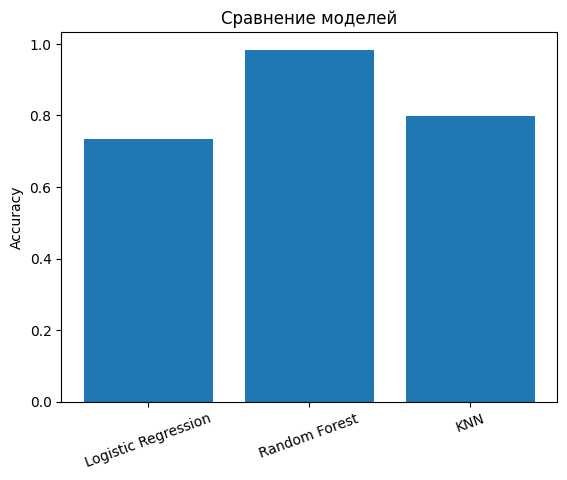

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Сравнение моделей")
plt.xticks(rotation=20)
plt.show()

**Анализ качества моделей с использованием матрицы ошибок**. Для оценки качества моделей использовалась матрица ошибок, позволяющая проанализировать структуру классификационных ошибок.

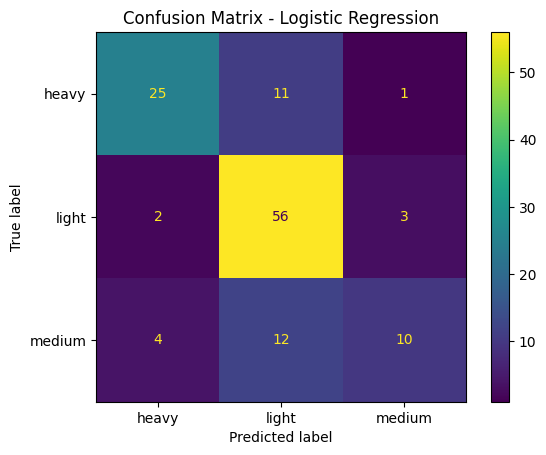

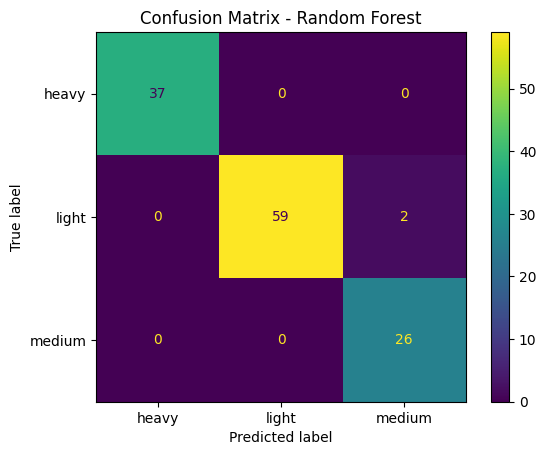

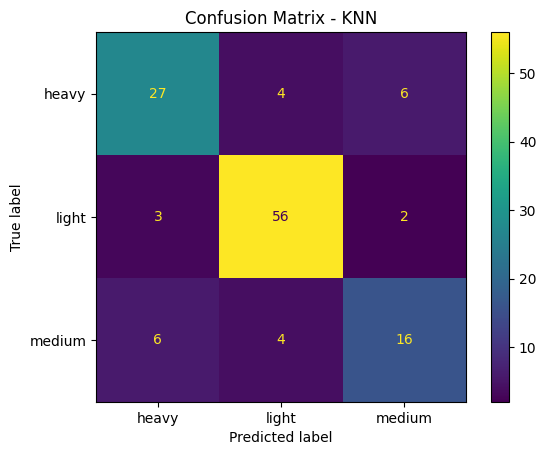

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:
        pred = model.predict(X_test_scaled)
    else:
        pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

**Анализ важности признаков**. Выполнен анализ важности признаков для модели случайного леса с визуализацией результатов.

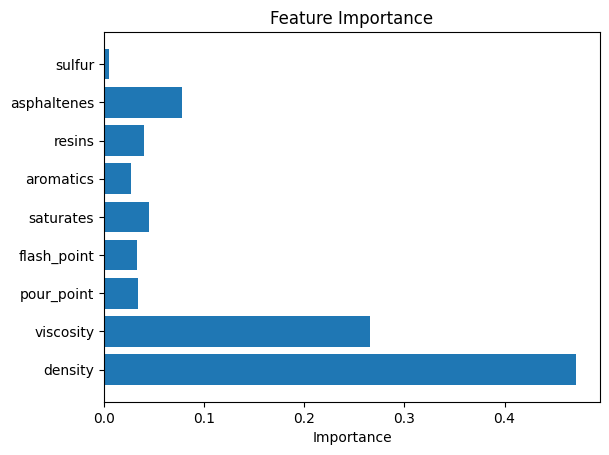

       Feature  Importance
0      density    0.471687
1    viscosity    0.266107
7  asphaltenes    0.078361
4    saturates    0.045018
6       resins    0.039930
2   pour_point    0.034447
3  flash_point    0.033034
5    aromatics    0.026831
8       sulfur    0.004587


In [26]:
# Важность признаков для Random Forest
importances = models["Random Forest"].feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()
print(feat_df)

**Построение ROC-кривых и оценка качества классификации**. Построены ROC-кривые (One-vs-Rest) и рассчитаны значения AUC для оценки качества классификации.

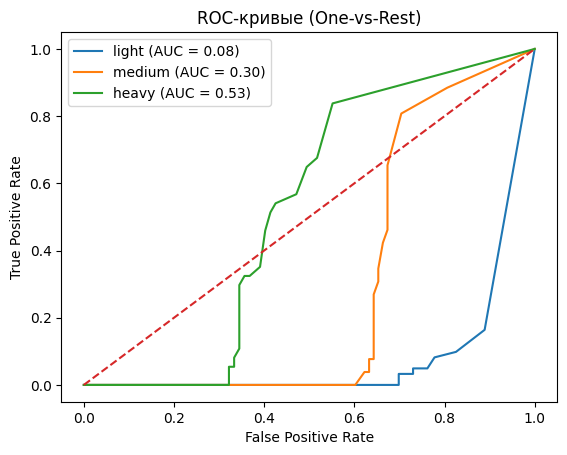

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Бинаризация классов
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

# Берем лучшую модель (обычно RandomForest)
model = models["Random Forest"]

# Получаем вероятности
y_score = model.predict_proba(X_test)

# ROC для каждого класса
plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые (One-vs-Rest)")
plt.legend()
plt.show()

**Сохранение обученной модели**. Обученная модель сохранена в файл для последующего использования.

In [28]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))